# Austin Animal Center Adoption Return Analysis

## Objective

This analysis examines factors associated with animals returning to the Austin Animal Center after adoption.

The primary outcome is whether an adoption is followed by another recorded shelter intake within 30 days.

Each observation represents an **adoption event**, rather than an individual animal, because the same animal may be adopted multiple times during the study period.

### Primary Question

**Which factors are associated with adopted animals returning to the Austin Animal Center within 30 days?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
intakes_path = "../data/raw/Austin_Animal_Center_Intakes_(10_01_2013_to_05_05_2025)_20260930.csv"
outcomes_path = "../data/raw/Austin_Animal_Center_Outcomes_(10_01_2013_to_05_05_2025)_20260930.csv"

intakes_raw = pd.read_csv(intakes_path)
outcomes_raw = pd.read_csv(outcomes_path)

print("Intakes:", intakes_raw.shape)
print("Outcomes:", outcomes_raw.shape)

Intakes: (173812, 12)
Outcomes: (173775, 12)


# Count exact duplicate rows
print("Duplicate intake rows:", intakes_raw.duplicated().sum())
print("Duplicate outcome rows:", outcomes_raw.duplicated().sum())

# Remove exact duplicates
intakes = intakes_raw.drop_duplicates().copy()
outcomes = outcomes_raw.drop_duplicates().copy()

print("\nAfter removing duplicates:")
print("Intakes:", intakes.shape)
print("Outcomes:", outcomes.shape)

### Timestamp Standardization

The outcome dataset contains mixed timestamp formats. Most records contain a standard date and time, while a small subset contains a timezone offset and a time of exactly midnight.

Exploratory analysis found that all offset-formatted records used `00:00:00`, suggesting that these records have lower time-of-day precision. Because the analysis focuses on 30-day returns rather than hour-level behavior, timestamps are standardized as timezone-naive values while preserving the date and clock time recorded in the source data.

In [3]:
# Check the raw source datasets for exact duplicate rows.
# Duplicate events could cause the same shelter event to be counted more than once.
print("Duplicate intake rows:", intakes_raw.duplicated().sum())
print("Duplicate outcome rows:", outcomes_raw.duplicated().sum())

# Create cleaned copies with exact duplicate rows removed.
# The raw DataFrames remain unchanged for reference and data-quality checks.
intakes = intakes_raw.drop_duplicates().copy()
outcomes = outcomes_raw.drop_duplicates().copy()

# Verify the number of records remaining after duplicate removal.
print("\nAfter removing duplicates:")
print("Intakes:", intakes.shape)
print("Outcomes:", outcomes.shape)

Duplicate intake rows: 36
Duplicate outcome rows: 26

After removing duplicates:
Intakes: (173776, 12)
Outcomes: (173749, 12)


In [4]:
# Remove timezone suffixes such as "-05:00" from outcome timestamps.
# This preserves the date and clock time exactly as recorded rather than
# converting these records to UTC and shifting their time by several hours.
outcomes["DateTime"] = outcomes["DateTime"].str.replace(
    r"[+-]\d{2}:\d{2}$",
    "",
    regex=True
)

# Convert the cleaned outcome timestamps into pandas datetime values.
# format="mixed" allows pandas to handle the different timestamp formats
# present in the source data.
outcomes["DateTime"] = pd.to_datetime(
    outcomes["DateTime"],
    format="mixed"
)

# Convert intake timestamps to pandas datetime values as well.
# Both datasets now use comparable timezone-naive datetime values.
intakes["DateTime"] = pd.to_datetime(
    intakes["DateTime"]
)

# Verify that both columns were successfully converted.
print("Intake DateTime:", intakes["DateTime"].dtype)
print("Outcome DateTime:", outcomes["DateTime"].dtype)

Intake DateTime: datetime64[us]
Outcome DateTime: datetime64[us]


# Identify raw outcome timestamps that contain an explicit timezone offset.
# We inspect the raw data here because the timezone suffixes have already
# been removed from the cleaned outcomes DataFrame.
has_offset = outcomes_raw["DateTime"].str.contains(
    r"[+-]\d{2}:\d{2}$",
    regex=True,
    na=False
)

# Extract the time-of-day portion from the offset-formatted timestamps.
# This lets us determine whether these records contain meaningful clock times.
offset_times = outcomes_raw.loc[
    has_offset, "DateTime"
].str.extract(r"T(\d{2}:\d{2}:\d{2})")[0]

# Summarize how many records use the offset format and what times they contain.
print("Outcome records with timezone offsets:", has_offset.sum())
print("\nTime values among offset-formatted records:")
print(offset_times.value_counts())

## Identify Adoption Events

The outcomes dataset contains many types of shelter events, including adoptions, transfers, returns to owner, and other outcomes.

For this analysis, we isolate records where `Outcome Type` is `Adoption`. Each adoption event becomes the starting point for determining whether the animal subsequently returns to the shelter within 30 days.

# Keep only outcome records where the animal's outcome was an adoption.
# Each row represents an adoption event that can be evaluated for a subsequent return.
adoptions = outcomes[
    outcomes["Outcome Type"] == "Adoption"
].copy()

# Display the number of adoption events available for the analysis.
print("Adoption events:", len(adoptions))

# Show the distribution of adoption subtypes.
# This helps us understand the types of adoption events represented in the data.
print("\nAdoption subtypes:")
print(adoptions["Outcome Subtype"].value_counts(dropna=False))

## Match Adoptions to Subsequent Shelter Intakes

For each adoption event, the analysis looks for the next recorded intake for the same animal.

Only intakes occurring **strictly after** the adoption are eligible. The next intake is used to determine whether the animal returned to the shelter within 30 days.

The analysis treats each adoption event independently because an animal can have multiple adoption events over the study period.

In [5]:
# Keep only outcome records where the recorded outcome was an adoption.
# Each row represents one adoption event, so the same animal can appear
# more than once if it was adopted multiple times.
adoptions = outcomes[
    outcomes["Outcome Type"] == "Adoption"
].copy()

# Check how many adoption events are in the cleaned dataset.
print("Adoption events:", len(adoptions))

Adoption events: 84586


In [6]:
# Keep only the fields needed to match adoption events to later intakes.
# Renaming the datetime columns makes their roles explicit after the merge.
adoptions_match = adoptions[
    [
        "Animal ID",
        "DateTime",
        "Outcome Type",
        "Outcome Subtype",
        "Animal Type",
        "Sex upon Outcome",
        "Age upon Outcome",
        "Breed",
        "Color"
    ]
].copy()

intakes_match = intakes[
    ["Animal ID", "DateTime", "Intake Type"]
].copy()

# Rename the datetime fields so we can clearly distinguish the adoption
# timestamp from the subsequent intake timestamp.
adoptions_match = adoptions_match.rename(
    columns={"DateTime": "Adoption DateTime"}
)

intakes_match = intakes_match.rename(
    columns={"DateTime": "Intake DateTime"}
)

# merge_asof requires the data to be sorted by the time column.
# Sorting within Animal ID ensures each animal's events are in chronological order.
adoptions_match = adoptions_match.sort_values(
    ["Animal ID", "Adoption DateTime"]
)

intakes_match = intakes_match.sort_values(
    ["Animal ID", "Intake DateTime"]
)

print("Adoption events:", len(adoptions_match))
print("Intake events:", len(intakes_match))

Adoption events: 84586
Intake events: 173776


# merge_asof requires the merge datetime columns to be globally sorted.
# Sort by datetime first, then Animal ID to maintain chronological order
# while keeping each animal's events identifiable.
adoptions_match = adoptions_match.sort_values(
    ["Adoption DateTime", "Animal ID"]
).reset_index(drop=True)

intakes_match = intakes_match.sort_values(
    ["Intake DateTime", "Animal ID"]
).reset_index(drop=True)

# Match each adoption to the first intake recorded after that adoption
# for the same animal.
#
# allow_exact_matches=False prevents an intake at the exact same timestamp
# from being classified as a return.
adoption_returns = pd.merge_asof(
    adoptions_match,
    intakes_match,
    left_on="Adoption DateTime",
    right_on="Intake DateTime",
    by="Animal ID",
    direction="forward",
    allow_exact_matches=False
)

# Calculate the number of days between the adoption and the next intake.
adoption_returns["Days to Next Intake"] = (
    adoption_returns["Intake DateTime"]
    - adoption_returns["Adoption DateTime"]
).dt.total_seconds() / 86400

# Verify that the merge produced one row for every adoption event.
print("Adoption events:", len(adoptions_match))
print("Matched adoption events:", len(adoption_returns))

## Define the 30-Day Return Outcome

An adoption is classified as a **30-day return** when the animal's next recorded shelter intake occurs more than 0 days and no more than 30 days after the adoption.

Adoptions without a subsequent intake are classified as not returned within 30 days.

This definition uses the next recorded intake for the same animal and prevents an intake occurring at the exact adoption timestamp from being counted as a return.

In [7]:
# Sort both datasets by their datetime key before using merge_asof.
# merge_asof requires the matching datetime columns to be globally sorted.
adoptions_match = adoptions_match.sort_values(
    ["Adoption DateTime", "Animal ID"]
).reset_index(drop=True)

intakes_match = intakes_match.sort_values(
    ["Intake DateTime", "Animal ID"]
).reset_index(drop=True)


# Match each adoption to the next recorded intake for the same animal.
# direction="forward" searches forward in time from the adoption.
# Exact timestamp matches are excluded because a return must occur after adoption.
adoption_returns = pd.merge_asof(
    adoptions_match,
    intakes_match,
    left_on="Adoption DateTime",
    right_on="Intake DateTime",
    by="Animal ID",
    direction="forward",
    allow_exact_matches=False
)


# Calculate the number of days between adoption and the next recorded intake.
adoption_returns["Days to Next Intake"] = (
    adoption_returns["Intake DateTime"]
    - adoption_returns["Adoption DateTime"]
).dt.total_seconds() / 86400


# Verify that every adoption event remains represented after the match.
print("Adoption events:", len(adoptions_match))
print("Matched adoption events:", len(adoption_returns))

Adoption events: 84586
Matched adoption events: 84586


In [8]:
# Identify adoption events where a subsequent shelter intake was recorded
# within the 30-day observation window.
adoption_returns["Returned_30"] = (
    adoption_returns["Days to Next Intake"].notna()
    & (adoption_returns["Days to Next Intake"] > 0)
    & (adoption_returns["Days to Next Intake"] <= 30)
)

# Show the number and proportion of adoption events in each outcome group.
print(adoption_returns["Returned_30"].value_counts())
print("\nProportion:")
print(adoption_returns["Returned_30"].value_counts(normalize=True))

Returned_30
False    79182
True      5404
Name: count, dtype: int64

Proportion:
Returned_30
False    0.936112
True     0.063888
Name: proportion, dtype: float64


## Ensure a Complete 30-Day Observation Window

An adoption can only be classified as a non-return if the dataset contains at least 30 days of subsequent shelter records.

Adoptions occurring near the end of the study period may not have enough follow-up time to determine whether a 30-day return occurred. These observations are excluded from the modeling cohort rather than being treated as non-returns.

# Find the latest recorded intake date available in the analysis dataset.
# This represents the end of the observable shelter history.
last_intake_date = intakes_match["Intake DateTime"].max()

# Calculate how many days of follow-up are available after each adoption.
adoption_returns["Days of Available Follow-up"] = (
    last_intake_date - adoption_returns["Adoption DateTime"]
).dt.total_seconds() / 86400

# Identify adoption events with at least 30 complete days of follow-up.
adoption_returns["Has 30-Day Follow-up"] = (
    adoption_returns["Days of Available Follow-up"] >= 30
)

# Summarize how many adoption events have sufficient follow-up.
print(adoption_returns["Has 30-Day Follow-up"].value_counts())

## Create the 30-Day Analysis Cohort

The final cohort includes only adoption events with a complete 30-day observation window.

Adoption events occurring within the final 30 days of the intake dataset are excluded because we cannot determine whether they remained out of the shelter for the full 30-day period.

# Keep only adoption events with a complete 30-day observation window.
# This prevents incomplete follow-up from being incorrectly classified as
# a successful adoption.
analysis_data = adoption_returns[
    adoption_returns["Has 30-Day Follow-up"]
].copy()

# Confirm the final cohort size.
print("Final analysis cohort:", len(analysis_data))

# Check the distribution of the 30-day return outcome.
print("\n30-day return outcome:")
print(analysis_data["Returned_30"].value_counts())

# Calculate the overall 30-day return rate.
return_rate = analysis_data["Returned_30"].mean()

print(f"\n30-day return rate: {return_rate:.2%}")

## Feature Preparation

The analysis uses animal characteristics and adoption history as predictors of 30-day return.

The initial features include:

- Animal type
- Sex/reproductive status at outcome
- Age at adoption
- Prior recorded shelter history
- Time from intake to adoption

These variables are used to examine associations with the 30-day return outcome.

In [9]:
# Display the columns currently available in the adoption-level dataset.
# This confirms which features are already available and prevents unnecessary
# merges that could introduce duplicate columns or mismatched records.
print(adoption_returns.columns.tolist())

['Animal ID', 'Adoption DateTime', 'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color', 'Intake DateTime', 'Intake Type', 'Days to Next Intake', 'Returned_30']


In [10]:
# Create separate copies for the feature-matching step.
# This keeps the original cleaned datasets unchanged.
intakes_features = intakes.copy()
adoptions_features = adoption_returns.copy()

# merge_asof() requires the datetime merge keys to be globally sorted.
# Sort by the timestamp first, then Animal ID.
intakes_features = intakes_features.sort_values(
    ["DateTime", "Animal ID"]
).reset_index(drop=True)

adoptions_features = adoptions_features.sort_values(
    ["Adoption DateTime", "Animal ID"]
).reset_index(drop=True)

# Match each adoption to the most recent intake for that animal
# that occurred strictly before the adoption.
adoption_features = pd.merge_asof(
    adoptions_features,
    intakes_features,
    left_on="Adoption DateTime",
    right_on="DateTime",
    by="Animal ID",
    direction="backward",
    allow_exact_matches=False,
    suffixes=("", "_intake")
)

# Verify the number of adoption events and how many have a
# preceding intake record available.
print("Adoption events:", len(adoptions_features))
print(
    "Adoption events with intake history:",
    adoption_features["DateTime"].notna().sum()
)

Adoption events: 84586
Adoption events with intake history: 83957


In [11]:
# Identify adoption events that do not have a preceding intake record.
missing_intake_history = adoption_features[
    adoption_features["DateTime"].isna()
].copy()

# Summarize these adoption events by outcome subtype.
# This helps determine whether the missing records are concentrated
# in a particular type of adoption event.
print("Adoptions without prior intake:", len(missing_intake_history))
print("\nOutcome subtype:")
print(
    missing_intake_history["Outcome Subtype"]
    .value_counts(dropna=False)
)

Adoptions without prior intake: 629

Outcome subtype:
Outcome Subtype
NaN        392
Foster     220
Offsite     17
Name: count, dtype: int64


In [12]:
# Display the columns from the adoption-level dataset after matching
# each adoption to its most recent preceding intake.
#
# This lets us identify the fields needed to calculate age and other
# predictors without guessing at column names.
print(adoption_features.columns.tolist())

['Animal ID', 'Adoption DateTime', 'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color', 'Intake DateTime', 'Intake Type', 'Days to Next Intake', 'Returned_30', 'Name', 'DateTime', 'MonthYear', 'Found Location', 'Intake Type_intake', 'Intake Condition', 'Animal Type_intake', 'Sex upon Intake', 'Age upon Intake', 'Breed_intake', 'Color_intake']


In [13]:
# Convert the reported age at intake into years.
# The source data stores age using units such as days, weeks, months, and years.
# We standardize these values so age can be calculated consistently.
age_in_years = (
    adoption_features["Age upon Intake"]
    .astype(str)
    .str.extract(r"([\d.]+)")[0]
    .astype(float)
)

# Identify the unit used in the original age field.
age_unit = (
    adoption_features["Age upon Intake"]
    .astype(str)
    .str.extract(r"([A-Za-z]+)")[0]
    .str.lower()
)

# Convert the reported intake age to years based on its original unit.
adoption_features["Age at Intake Years"] = np.select(
    [
        age_unit.str.startswith("day"),
        age_unit.str.startswith("week"),
        age_unit.str.startswith("month"),
        age_unit.str.startswith("year")
    ],
    [
        age_in_years / 365.25,
        age_in_years / 52.18,
        age_in_years / 12,
        age_in_years
    ],
    default=np.nan
)

# Calculate the number of years between the preceding intake and adoption.
# This allows us to estimate the animal's age at the time of adoption.
adoption_features["Years from Intake to Adoption"] = (
    adoption_features["Adoption DateTime"]
    - adoption_features["DateTime"]
).dt.total_seconds() / (365.25 * 86400)

# Calculate estimated age at adoption.
adoption_features["Age Years"] = (
    adoption_features["Age at Intake Years"]
    + adoption_features["Years from Intake to Adoption"]
)

# Display a few records to verify the calculation.
adoption_features[
    [
        "Animal ID",
        "Age upon Intake",
        "Age at Intake Years",
        "Years from Intake to Adoption",
        "Age Years"
    ]
].head()

,Animal ID,Age upon Intake,Age at Intake Years,Years from Intake to Adoption,Age Years
0,A659834,NaN,NaN,NaN,NaN
1,A663572,NaN,NaN,NaN,NaN
2,A656894,NaN,NaN,NaN,NaN
3,A661795,NaN,NaN,NaN,NaN
4,A662104,NaN,NaN,NaN,NaN


In [14]:
# Inspect the first few rows of the matched adoption dataset.
# We are checking which values actually belong to each column before
# continuing with feature engineering.
adoption_features[
    ["Animal ID", "Name", "DateTime", "Animal Type", "Sex upon Intake", "Age upon Intake"]
].head(10)

,Animal ID,Name,DateTime,Animal Type,Sex upon Intake,Age upon Intake
0,A659834,NaN,NaT,Dog,NaN,NaN
1,A663572,NaN,NaT,Dog,NaN,NaN
2,A656894,NaN,NaT,Cat,NaN,NaN
3,A661795,NaN,NaT,Cat,NaN,NaN
4,A662104,NaN,NaT,Dog,NaN,NaN
5,A660634,NaN,NaT,Cat,NaN,NaN
6,A663920,NaN,NaT,Cat,NaN,NaN
7,A663827,NaN,NaT,Dog,NaN,NaN
8,A664032,NaN,NaT,Dog,NaN,NaN
9,A664031,NaN,NaT,Dog,NaN,NaN


In [15]:
# Inspect the original cleaned intake data to verify the source column
# structure and confirm where the actual Animal ID is stored.
intakes[
    ["Animal ID", "Name", "DateTime", "Animal Type", "Sex upon Intake", "Age upon Intake"]
].head(10)

,Animal ID,Name,DateTime,Animal Type,Sex upon Intake,Age upon Intake
0,A521520,Nina,2013-10-01 07:51:00,Dog,Spayed Female,7 years
1,A664235,NaN,2013-10-01 08:33:00,Cat,Unknown,1 week
2,A664236,NaN,2013-10-01 08:33:00,Cat,Unknown,1 week
3,A664237,NaN,2013-10-01 08:33:00,Cat,Unknown,1 week
4,A664233,Stevie,2013-10-01 08:53:00,Dog,Intact Female,3 years
5,A664238,NaN,2013-10-01 09:33:00,Cat,Unknown,4 months
6,A664234,NaN,2013-10-01 10:37:00,Dog,Intact Male,8 years
7,A664256,*Donnie,2013-10-01 10:59:00,Cat,Neutered Male,17 years
8,A664257,Pippin,2013-10-01 11:01:00,Dog,Intact Female,4 years
9,A664266,NaN,2013-10-01 11:09:00,Dog,Intact Female,1 year


In [16]:
# Display adoption events that successfully matched to a preceding intake.
# Unmatched adoptions have missing intake fields, so filtering them out here
# lets us verify that the matched intake characteristics are aligned correctly.
adoption_features.loc[
    adoption_features["DateTime"].notna(),
    [
        "Animal ID",
        "Adoption DateTime",
        "DateTime",
        "Animal Type",
        "Sex upon Intake",
        "Age upon Intake"
    ]
].head(10)

,Animal ID,Adoption DateTime,DateTime,Animal Type,Sex upon Intake,Age upon Intake
14,A634503,2013-10-02 12:40:00,2013-10-01 14:49:00,Dog,Spayed Female,2 years
76,A664483,2013-10-05 18:23:00,2013-10-04 10:46:00,Dog,Intact Male,2 months
77,A664482,2013-10-05 18:24:00,2013-10-04 10:46:00,Dog,Intact Male,2 months
86,A664484,2013-10-06 11:53:00,2013-10-04 10:46:00,Dog,Intact Female,2 months
99,A664305,2013-10-06 17:08:00,2013-10-01 16:10:00,Dog,Intact Female,1 month
100,A664481,2013-10-06 17:18:00,2013-10-04 10:46:00,Dog,Intact Male,2 months
101,A664300,2013-10-06 17:21:00,2013-10-01 16:10:00,Dog,Intact Male,1 month
102,A664287,2013-10-06 17:27:00,2013-10-01 15:38:00,Dog,Intact Female,4 months
109,A664301,2013-10-06 18:06:00,2013-10-01 16:10:00,Dog,Intact Female,1 month
124,A664590,2013-10-07 16:59:00,2013-10-05 14:14:00,Dog,Intact Female,3 months


In [17]:
# Inspect the age values recorded at the time of adoption.
# We do this before converting age to a numeric value so we can identify
# unexpected formats or missing values in the source data.

print(
    analysis_data["Age upon Outcome"]
    .value_counts(dropna=False)
    .sort_index()
)

NameError: name 'analysis_data' is not defined

In [18]:
%whos

Variable                 Type         Data/Info
-----------------------------------------------
adoption_features        DataFrame    Shape: (84586, 27)
adoption_returns         DataFrame    Shape: (84586, 13)
adoptions                DataFrame    Shape: (84586, 12)
adoptions_features       DataFrame    Shape: (84586, 13)
adoptions_match          DataFrame    Shape: (84586, 9)
age_in_years             Series       Shape: (84586,)
age_unit                 Series       Shape: (84586,)
intakes                  DataFrame    Shape: (173776, 12)
intakes_features         DataFrame    Shape: (173776, 12)
intakes_match            DataFrame    Shape: (173776, 3)
intakes_path             str          ../data/raw/Austin_Animal<...>_05_05_2025)_20260930.csv
intakes_raw              DataFrame    Shape: (173812, 12)
missing_intake_history   DataFrame    Shape: (629, 24)
np                       module       <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
outcomes                 DataFrame    

In [19]:
adoption_features.columns.tolist()

['Animal ID',
 'Adoption DateTime',
 'Outcome Type',
 'Outcome Subtype',
 'Animal Type',
 'Sex upon Outcome',
 'Age upon Outcome',
 'Breed',
 'Color',
 'Intake DateTime',
 'Intake Type',
 'Days to Next Intake',
 'Returned_30',
 'Name',
 'DateTime',
 'MonthYear',
 'Found Location',
 'Intake Type_intake',
 'Intake Condition',
 'Animal Type_intake',
 'Sex upon Intake',
 'Age upon Intake',
 'Breed_intake',
 'Color_intake',
 'Age at Intake Years',
 'Years from Intake to Adoption',
 'Age Years']

In [20]:
# Inspect the original age-at-adoption values.
print(
    adoption_features["Age upon Outcome"]
    .value_counts(dropna=False)
    .sort_index()
)

Age upon Outcome
-1 years         1
-3 years         1
-4 years         1
0 years         11
1 month       3174
1 weeks          2
1 year       13068
10 months     1479
10 years       727
11 months      687
11 years       297
12 years       307
13 years       203
14 years       118
15 years        93
16 years        38
17 years        17
18 years        13
19 years         1
2 months     19660
2 weeks          6
2 years      11460
20 years         1
3 days           1
3 months      7174
3 weeks         20
3 years       4014
4 months      4227
4 weeks         17
4 years       2324
5 days          11
5 months      2850
5 weeks          2
5 years       2019
6 months      2365
6 years       1264
7 months      1407
7 years       1114
8 months      1642
8 years       1140
9 months       970
9 years        660
Name: count, dtype: int64


In [21]:
# Check the numeric age feature that has already been created.
print(adoption_features["Age Years"].describe())

print("\nMissing values:")
print(adoption_features["Age Years"].isna().sum())

count    83957.000000
mean         1.590858
std          2.334494
min          0.003179
25%          0.202451
50%          0.683885
75%          2.025019
max         20.006364
Name: Age Years, dtype: float64

Missing values:
629


In [22]:
# Compare the recorded adoption age with the existing numeric age feature.

adoption_features[
    ["Age upon Outcome", "Age at Intake Years", 
     "Years from Intake to Adoption", "Age Years"]
].head(20)

,Age upon Outcome,Age at Intake Years,Years from Intake to Adoption,Age Years
0,2 months,NaN,NaN,NaN
1,3 years,NaN,NaN,NaN
2,5 months,NaN,NaN,NaN
3,6 months,NaN,NaN,NaN
4,3 years,NaN,NaN,NaN
5,2 months,NaN,NaN,NaN
6,2 months,NaN,NaN,NaN
7,8 months,NaN,NaN,NaN
8,2 months,NaN,NaN,NaN
9,2 months,NaN,NaN,NaN


In [23]:
def convert_age_to_years(age):
    if pd.isna(age):
        return np.nan

    value, unit = age.split()
    value = int(value)

    # Negative ages are invalid source-data values.
    if value < 0:
        return np.nan

    if "day" in unit:
        return value / 365
    elif "week" in unit:
        return value / 52
    elif "month" in unit:
        return value / 12
    elif "year" in unit:
        return float(value)

    return np.nan


adoption_features["Age at Adoption Years"] = (
    adoption_features["Age upon Outcome"]
    .apply(convert_age_to_years)
)

In [24]:
print(adoption_features["Age at Adoption Years"].describe())

print("\nMissing values:")
print(adoption_features["Age at Adoption Years"].isna().sum())

count    84583.000000
mean         1.567241
std          2.327485
min          0.000000
25%          0.166667
50%          0.666667
75%          2.000000
max         20.000000
Name: Age at Adoption Years, dtype: float64

Missing values:
3


In [25]:
# Group animals into interpretable age categories.

age_bins = [-0.001, 0.5, 1, 3, 7, np.inf]

age_labels = [
    "Under 6 months",
    "6–12 months",
    "1–3 years",
    "3–7 years",
    "7+ years"
]

adoption_features["Age Group"] = pd.cut(
    adoption_features["Age at Adoption Years"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

In [26]:
adoption_features["Age Group"].value_counts(
    dropna=False
).sort_index()

Age Group
Under 6 months    37155
6–12 months        8550
1–3 years         24528
3–7 years          9621
7+ years           4729
NaN                   3
Name: count, dtype: int64

In [27]:
# Calculate adoption count, number of 30-day returns,
# and return rate for each age group.

age_return_summary = (
    adoption_features
    .groupby("Age Group", observed=True)
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)

age_return_summary["Return Rate %"] = (
    age_return_summary["Return_Rate"] * 100
).round(2)

age_return_summary

,Age Group,Adoptions,Returns,Return_Rate,Return Rate %
0,Under 6 months,37155,1196,0.032189,3.22
1,6–12 months,8550,588,0.068772,6.88
2,1–3 years,24528,2318,0.094504,9.45
3,3–7 years,9621,940,0.097703,9.77
4,7+ years,4729,362,0.076549,7.65


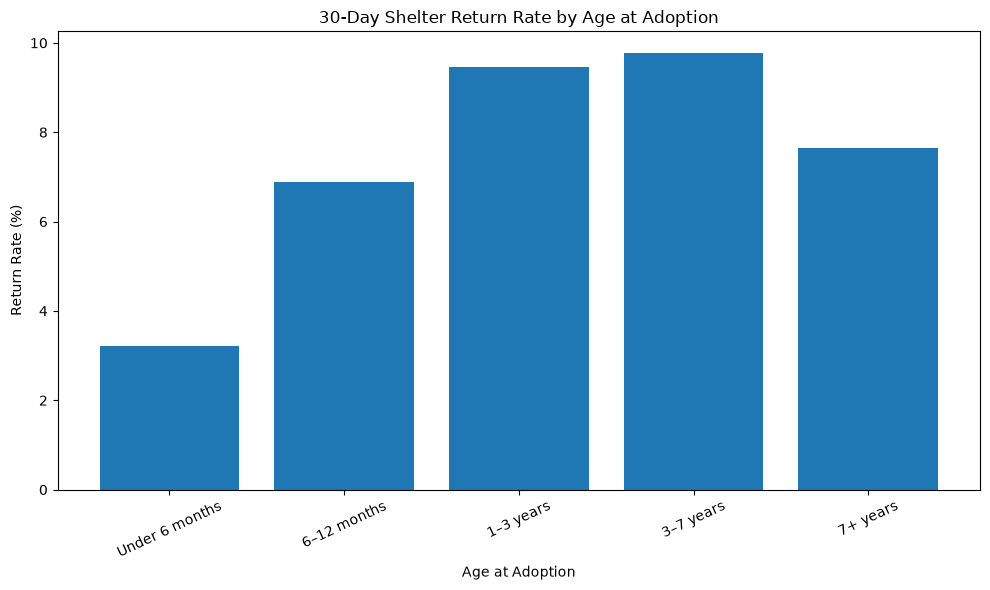

In [28]:
# Visualize 30-day return rate by age group.

plt.figure(figsize=(10, 6))

plt.bar(
    age_return_summary["Age Group"].astype(str),
    age_return_summary["Return Rate %"]
)

plt.title("30-Day Shelter Return Rate by Age at Adoption")
plt.xlabel("Age at Adoption")
plt.ylabel("Return Rate (%)")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [29]:
# Check the animal types represented in the adoption dataset.

adoption_features["Animal Type"].value_counts(dropna=False)

Animal Type
Dog          47469
Cat          35776
Other         1001
Bird           323
Livestock       17
Name: count, dtype: int64

In [30]:
# Calculate 30-day return rates by animal type.

animal_type_summary = (
    adoption_features
    .groupby("Animal Type")
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)

animal_type_summary["Return Rate %"] = (
    animal_type_summary["Return_Rate"] * 100
).round(2)

animal_type_summary = animal_type_summary.sort_values(
    "Return Rate %",
    ascending=False
)

animal_type_summary

,Animal Type,Adoptions,Returns,Return_Rate,Return Rate %
2,Dog,47469,4282,0.090206,9.02
1,Cat,35776,1107,0.030943,3.09
4,Other,1001,14,0.013986,1.40
0,Bird,323,1,0.003096,0.31
3,Livestock,17,0,0.000000,0.00


In [31]:
# Compare return rates across age groups separately for dogs and cats.

dog_cat_age_summary = (
    adoption_features[
        adoption_features["Animal Type"].isin(["Dog", "Cat"])
    ]
    .groupby(
        ["Age Group", "Animal Type"],
        observed=True
    )
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)

dog_cat_age_summary["Return Rate %"] = (
    dog_cat_age_summary["Return_Rate"] * 100
).round(2)

dog_cat_age_summary

,Age Group,Animal Type,Adoptions,Returns,Return_Rate,Return Rate %
0,Under 6 months,Cat,23577,535,0.022692,2.27
1,Under 6 months,Dog,13381,658,0.049174,4.92
2,6–12 months,Cat,2623,74,0.028212,2.82
3,6–12 months,Dog,5723,513,0.089638,8.96
4,1–3 years,Cat,5567,264,0.047422,4.74
5,1–3 years,Dog,18128,2045,0.112809,11.28
6,3–7 years,Cat,2360,139,0.058898,5.89
7,3–7 years,Dog,7168,800,0.111607,11.16
8,7+ years,Cat,1648,95,0.057646,5.76
9,7+ years,Dog,3067,266,0.086730,8.67


In [32]:
animal_type_summary = (
    animal_type_summary
    .sort_values("Return Rate %", ascending=False)
    .reset_index(drop=True)
)

In [33]:
# Compare 30-day return rates across age groups
# separately for dogs and cats.

dog_cat_age_summary = (
    adoption_features[
        adoption_features["Animal Type"].isin(["Dog", "Cat"])
    ]
    .groupby(
        ["Age Group", "Animal Type"],
        observed=True
    )
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)

dog_cat_age_summary["Return Rate %"] = (
    dog_cat_age_summary["Return_Rate"] * 100
).round(2)

dog_cat_age_summary

,Age Group,Animal Type,Adoptions,Returns,Return_Rate,Return Rate %
0,Under 6 months,Cat,23577,535,0.022692,2.27
1,Under 6 months,Dog,13381,658,0.049174,4.92
2,6–12 months,Cat,2623,74,0.028212,2.82
3,6–12 months,Dog,5723,513,0.089638,8.96
4,1–3 years,Cat,5567,264,0.047422,4.74
5,1–3 years,Dog,18128,2045,0.112809,11.28
6,3–7 years,Cat,2360,139,0.058898,5.89
7,3–7 years,Dog,7168,800,0.111607,11.16
8,7+ years,Cat,1648,95,0.057646,5.76
9,7+ years,Dog,3067,266,0.086730,8.67


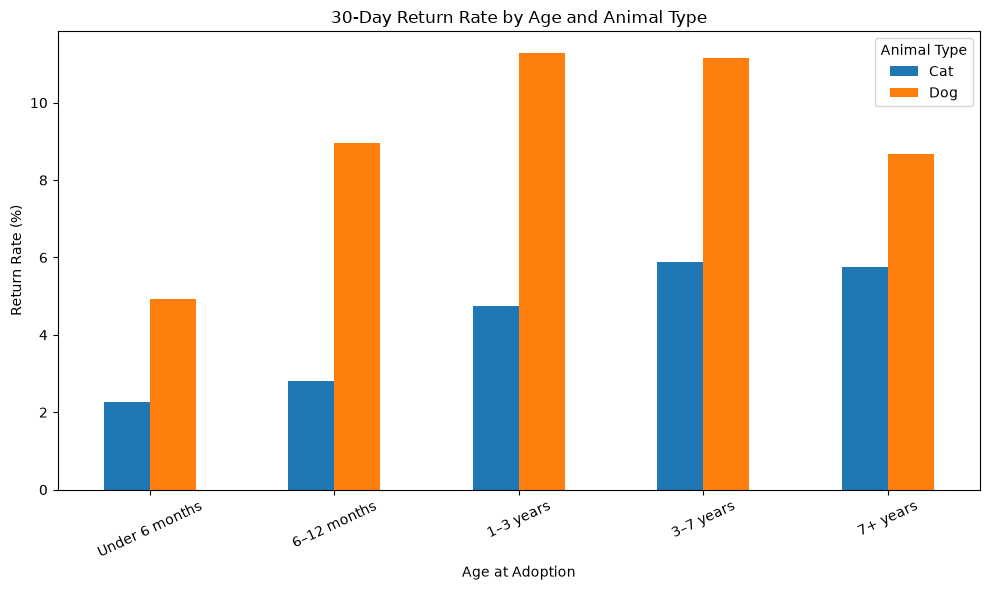

In [34]:
# Reshape the summary so dog and cat return rates
# can be plotted side by side.

age_type_plot = dog_cat_age_summary.pivot(
    index="Age Group",
    columns="Animal Type",
    values="Return Rate %"
)

age_type_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("30-Day Return Rate by Age and Animal Type")
plt.xlabel("Age at Adoption")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=25)

plt.legend(title="Animal Type")

plt.tight_layout()
plt.show()

In [35]:
# Inspect sex and spay/neuter status recorded at adoption.

adoption_features["Sex upon Outcome"].value_counts(dropna=False)

Sex upon Outcome
Neutered Male    40857
Spayed Female    39870
Intact Female     1874
Intact Male       1677
Unknown            308
Name: count, dtype: int64

In [36]:
# Calculate 30-day return rates by sex and spay/neuter status.

sex_status_summary = (
    adoption_features
    .groupby("Sex upon Outcome")
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)

sex_status_summary["Return Rate %"] = (
    sex_status_summary["Return_Rate"] * 100
).round(2)

sex_status_summary = (
    sex_status_summary
    .sort_values("Return Rate %", ascending=False)
    .reset_index(drop=True)
)

sex_status_summary

,Sex upon Outcome,Adoptions,Returns,Return_Rate,Return Rate %
0,Neutered Male,40857,2846,0.069658,6.97
1,Spayed Female,39870,2370,0.059443,5.94
2,Intact Male,1677,93,0.055456,5.55
3,Intact Female,1874,94,0.050160,5.02
4,Unknown,308,1,0.003247,0.32


In [37]:
# Compare sex/status return rates separately for dogs and cats.

dog_cat_sex_summary = (
    adoption_features[
        adoption_features["Animal Type"].isin(["Dog", "Cat"])
    ]
    .groupby(
        ["Sex upon Outcome", "Animal Type"]
    )
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)

dog_cat_sex_summary["Return Rate %"] = (
    dog_cat_sex_summary["Return_Rate"] * 100
).round(2)

dog_cat_sex_summary

,Sex upon Outcome,Animal Type,Adoptions,Returns,Return_Rate,Return Rate %
0,Intact Female,Cat,823,26,0.031592,3.16
1,Intact Female,Dog,704,62,0.088068,8.81
2,Intact Male,Cat,643,17,0.026439,2.64
3,Intact Male,Dog,655,70,0.106870,10.69
4,Neutered Male,Cat,16922,563,0.033270,3.33
5,Neutered Male,Dog,23745,2281,0.096062,9.61
6,Spayed Female,Cat,17387,501,0.028815,2.88
7,Spayed Female,Dog,22341,1869,0.083658,8.37
8,Unknown,Cat,1,0,0.000000,0.00
9,Unknown,Dog,24,0,0.000000,0.00


In [38]:
adoption_features[
    [
        "Animal ID",
        "Adoption DateTime",
        "Intake DateTime",
        "Intake Type",
        "Days to Next Intake",
        "Returned_30"
    ]
].head(20)

,Animal ID,Adoption DateTime,Intake DateTime,Intake Type,Days to Next Intake,Returned_30
0,A659834,2013-10-01 09:31:00,NaT,NaN,NaN,False
1,A663572,2013-10-01 11:42:00,2013-10-06 11:00:00,Owner Surrender,4.970833,True
2,A656894,2013-10-01 11:53:00,NaT,NaN,NaN,False
3,A661795,2013-10-01 11:53:00,NaT,NaN,NaN,False
4,A662104,2013-10-01 15:47:00,2014-01-27 13:34:00,Stray,117.907639,False
5,A660634,2013-10-01 16:17:00,NaT,NaN,NaN,False
6,A663920,2013-10-01 16:53:00,NaT,NaN,NaN,False
7,A663827,2013-10-01 17:02:00,NaT,NaN,NaN,False
8,A664032,2013-10-01 17:18:00,NaT,NaN,NaN,False
9,A664031,2013-10-01 18:24:00,NaT,NaN,NaN,False


In [39]:
# Count how many intake records exist for each animal.

intake_counts = (
    intakes
    .groupby("Animal ID")
    .size()
    .sort_values(ascending=False)
)

print(intake_counts.describe())

print("\nAnimals with more than one intake:")
print((intake_counts > 1).sum())

print("\nHighest intake counts:")
print(intake_counts.head(10))

count    156287.000000
mean          1.111903
std           0.429648
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          33.000000
dtype: float64

Animals with more than one intake:
13461

Highest intake counts:
Animal ID
A721033    33
A718223    14
A718877    12
A705625    12
A706536    11
A761266    10
A737814     9
A716018     9
A700407     9
A717053     9
dtype: int64


In [40]:
intakes.columns.tolist()

['Animal ID',
 'Name',
 'DateTime',
 'MonthYear',
 'Found Location',
 'Intake Type',
 'Intake Condition',
 'Animal Type',
 'Sex upon Intake',
 'Age upon Intake',
 'Breed',
 'Color']

In [41]:
# Match each adoption to all intake records for the same animal.
# We will then keep only intakes that happened BEFORE that adoption.

prior_intake_matches = (
    adoption_features[
        ["Animal ID", "Adoption DateTime", "Returned_30"]
    ]
    .merge(
        intakes[["Animal ID", "DateTime"]],
        on="Animal ID",
        how="left"
    )
)

prior_intake_matches.head(20)

,Animal ID,Adoption DateTime,Returned_30,DateTime
0,A659834,2013-10-01 09:31:00,False,NaT
1,A663572,2013-10-01 11:42:00,True,2013-10-06 11:00:00
2,A656894,2013-10-01 11:53:00,False,NaT
3,A661795,2013-10-01 11:53:00,False,NaT
4,A662104,2013-10-01 15:47:00,False,2014-01-27 13:34:00
5,A662104,2013-10-01 15:47:00,False,2014-03-09 10:57:00
6,A660634,2013-10-01 16:17:00,False,NaT
7,A663920,2013-10-01 16:53:00,False,NaT
8,A663827,2013-10-01 17:02:00,False,NaT
9,A664032,2013-10-01 17:18:00,False,NaT


In [42]:
# Keep only intake events that occurred BEFORE the adoption.

prior_intakes_only = prior_intake_matches[
    prior_intake_matches["DateTime"]
    < prior_intake_matches["Adoption DateTime"]
].copy()

prior_intakes_only.head(20)

,Animal ID,Adoption DateTime,Returned_30,DateTime
15,A634503,2013-10-02 12:40:00,False,2013-10-01 14:49:00
77,A664483,2013-10-05 18:23:00,False,2013-10-04 10:46:00
78,A664482,2013-10-05 18:24:00,False,2013-10-04 10:46:00
87,A664484,2013-10-06 11:53:00,False,2013-10-04 10:46:00
100,A664305,2013-10-06 17:08:00,False,2013-10-01 16:10:00
101,A664481,2013-10-06 17:18:00,False,2013-10-04 10:46:00
102,A664300,2013-10-06 17:21:00,False,2013-10-01 16:10:00
103,A664287,2013-10-06 17:27:00,False,2013-10-01 15:38:00
110,A664301,2013-10-06 18:06:00,False,2013-10-01 16:10:00
125,A664590,2013-10-07 16:59:00,False,2013-10-05 14:14:00


In [43]:
# Count all intake records occurring before each specific adoption.

pre_adoption_counts = (
    prior_intakes_only
    .groupby(["Animal ID", "Adoption DateTime"])
    .size()
    .reset_index(name="Pre-Adoption Intakes")
)

pre_adoption_counts["Previous Intakes"] = (
    pre_adoption_counts["Pre-Adoption Intakes"] - 1
)

pre_adoption_counts.head(20)

,Animal ID,Adoption DateTime,Pre-Adoption Intakes,Previous Intakes
0,A200922,2013-11-22 09:44:00,1,0
1,A210457,2016-10-07 12:34:00,1,0
2,A226069,2015-10-29 15:00:00,1,0
3,A249087,2016-11-15 10:37:00,1,0
4,A274546,2013-11-16 12:24:00,1,0
5,A281542,2014-05-19 12:32:00,1,0
6,A282897,2013-12-28 17:05:00,1,0
7,A282897,2015-07-11 16:49:00,2,1
8,A295822,2015-05-09 18:47:00,1,0
9,A302820,2014-07-25 10:30:00,1,0


In [44]:
# Add previous shelter history to the main adoption dataset.

adoption_features = adoption_features.merge(
    pre_adoption_counts[
        ["Animal ID", "Adoption DateTime", "Previous Intakes"]
    ],
    on=["Animal ID", "Adoption DateTime"],
    how="left"
)

adoption_features["Previous Intakes"] = (
    adoption_features["Previous Intakes"]
    .fillna(0)
    .astype(int)
)

adoption_features["Previous Intakes"].value_counts().sort_index()

Previous Intakes
0    75384
1     7368
2     1337
3      341
4      102
5       33
6       15
7        4
8        2
Name: count, dtype: int64

In [45]:
# Group previous shelter history into interpretable categories.

adoption_features["Previous Intake Group"] = pd.cut(
    adoption_features["Previous Intakes"],
    bins=[-1, 0, 1, np.inf],
    labels=["0", "1", "2+"]
)

history_return_summary = (
    adoption_features
    .groupby("Previous Intake Group", observed=True)
    .agg(
        Adoptions=("Returned_30", "size"),
        Returns=("Returned_30", "sum"),
        Return_Rate=("Returned_30", "mean")
    )
    .reset_index()
)

history_return_summary["Return Rate %"] = (
    history_return_summary["Return_Rate"] * 100
).round(2)

history_return_summary

,Previous Intake Group,Adoptions,Returns,Return_Rate,Return Rate %
0,0,75384,4321,0.057320,5.73
1,1,7368,813,0.110342,11.03
2,2+,1834,270,0.147219,14.72


In [46]:
# Inspect the final analysis DataFrame from the previous stage.
# We are checking its size and columns before saving it for use
# in the final presentation notebook.

print("Rows:", f"{len(adoption_features):,}")
print("Columns:", adoption_features.shape[1])

print("\nAvailable columns:")
print(adoption_features.columns.tolist())

Rows: 84,586
Columns: 31

Available columns:
['Animal ID', 'Adoption DateTime', 'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color', 'Intake DateTime', 'Intake Type', 'Days to Next Intake', 'Returned_30', 'Name', 'DateTime', 'MonthYear', 'Found Location', 'Intake Type_intake', 'Intake Condition', 'Animal Type_intake', 'Sex upon Intake', 'Age upon Intake', 'Breed_intake', 'Color_intake', 'Age at Intake Years', 'Years from Intake to Adoption', 'Age Years', 'Age at Adoption Years', 'Age Group', 'Previous Intakes', 'Previous Intake Group']


In [47]:
# Restrict the dataset to adoption events with a complete 30-day
# follow-up period. Adoptions occurring too close to the end of the
# available data cannot be observed for the full 30-day return window.

data_end_date = intakes["DateTime"].max()

analysis_data = adoption_features[
    adoption_features["Adoption DateTime"]
    <= (data_end_date - pd.Timedelta(days=30))
].copy()


# Save the completed analysis-ready dataset.
# Notebook 3 will load this file directly so the cleaning and
# feature-engineering work does not need to be repeated.

analysis_data.to_csv(
    "../data/shelter_return_analysis.csv",
    index=False
)


# Validate the final cohort before moving to the presentation notebook.

print("Final analysis cohort:", f"{len(analysis_data):,}")
print("30-day returns:", f"{analysis_data['Returned_30'].sum():,}")
print(
    "Overall return rate:",
    f"{analysis_data['Returned_30'].mean() * 100:.2f}%"
)

Final analysis cohort: 84,143
30-day returns: 5,386
Overall return rate: 6.40%
